This is a Kaggle classification project focused on predicting customer churn. The dataset contains telecommunications customer data with various features related to services, contracts, and billing.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from lightgbm import LGBMClassifier

from src.components.utils import seed_everything
seed_everything(42)

ModuleNotFoundError: No module named 'src.components.utils'

In [88]:
train_data = pd.read_csv("./Data/train.csv")
train_data.head(5)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1000,1653.8500,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5000,3778.2000,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4000,5841.3500,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.7000,70.7000,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.4500,70.4500,Yes


## Data Quality Observations

### Missing Values
- Based on our initial check, there appear to be no missing values in the dataset
- This is excellent for modeling as we won't need to impute missing data
- However, we should still check for implicit missing values (e.g., "No internet service" categories)

### Data Types
- Most features are correctly typed (int64, float64, object)
- SeniorCitizen is stored as int64 but functions as a categorical variable
- Some numerical features might benefit from transformation due to skewness
- Categorical features are properly stored as object types

In [89]:
# Check for missing values in the dataset
print("Missing Values in Dataset:")
missing_values = train_data.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)

# Check data types
print("\nData Types:")
print(train_data.dtypes)

Missing Values in Dataset:
Series([], dtype: int64)

Data Types:
id                    int64
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [90]:
# No duplicated rows
train_data.duplicated().sum()

np.int64(0)

In [91]:
# Remove irrelevant identifier column, it has no useful information for the model
train_data = train_data.drop(columns=['id'])
train_data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [92]:
# Check for special categories that might represent missing or unknown values
cat_features = train_data.select_dtypes(include=['object', 'str']).columns.tolist()
print("Categorical Features and Their Unique Values:")
print("=" * 50)

for col in cat_features:
    unique_vals = train_data[col].unique()
    print(f"{col}: {len(unique_vals)} unique values")
    print(f"  Values: {sorted(unique_vals)}")
    print()

Categorical Features and Their Unique Values:
gender: 2 unique values
  Values: ['Female', 'Male']

Partner: 2 unique values
  Values: ['No', 'Yes']

Dependents: 2 unique values
  Values: ['No', 'Yes']

PhoneService: 2 unique values
  Values: ['No', 'Yes']

MultipleLines: 3 unique values
  Values: ['No', 'No phone service', 'Yes']

InternetService: 3 unique values
  Values: ['DSL', 'Fiber optic', 'No']

OnlineSecurity: 3 unique values
  Values: ['No', 'No internet service', 'Yes']

OnlineBackup: 3 unique values
  Values: ['No', 'No internet service', 'Yes']

DeviceProtection: 3 unique values
  Values: ['No', 'No internet service', 'Yes']

TechSupport: 3 unique values
  Values: ['No', 'No internet service', 'Yes']

StreamingTV: 3 unique values
  Values: ['No', 'No internet service', 'Yes']

StreamingMovies: 3 unique values
  Values: ['No', 'No internet service', 'Yes']

Contract: 3 unique values
  Values: ['Month-to-month', 'One year', 'Two year']

PaperlessBilling: 2 unique values
  Va

## Categorical Variables Distributions

This section examines the distribution of the categorical variables in the dataset. Understanding these distributions provides insight into customer demographics, service subscriptions, and account characteristics before moving to modeling or deeper analysis.

---

## 1. Customer Demographics & Household Information

### Gender
The gender distribution in the dataset is nearly balanced.

- Male and Female customers appear in almost equal proportions.
- This indicates that gender is unlikely to introduce significant bias in the dataset.
- Both groups are well represented for modeling and analysis.

### Partner
This feature indicates whether the customer has a partner.

- A slightly larger portion of customers report having a partner.
- However, the distribution is still relatively balanced between **Yes** and **No**.
- This variable may help capture household-related service needs or stability.

### Dependents
This variable shows whether customers have dependents.

- The majority of customers **do not have dependents**.
- Customers with dependents represent a noticeably smaller portion of the dataset.
- This may reflect the typical customer profile or household composition.

---

## 2. Telecommunication Services

### PhoneService
This variable indicates whether the customer subscribes to phone service.

- The **vast majority of customers have phone service**.
- Only a very small percentage do not subscribe.
- This suggests that phone service is a common baseline product among customers.

### MultipleLines
This feature shows whether customers have multiple phone lines.

- A large portion of customers **do not use multiple lines**.
- A similarly large portion **do have multiple lines**.
- A small group has **no phone service**, which explains the third category.
- Overall, the distribution between single-line and multiple-line users is fairly balanced.

---

## 3. Internet Services

### InternetService
This variable identifies the type of internet connection.

- **Fiber optic** is the most common internet service among customers.
- **DSL** represents a smaller but still significant portion.
- A notable group of customers **do not subscribe to internet service**.
- This feature may strongly influence customer behavior since internet services often drive additional subscriptions.

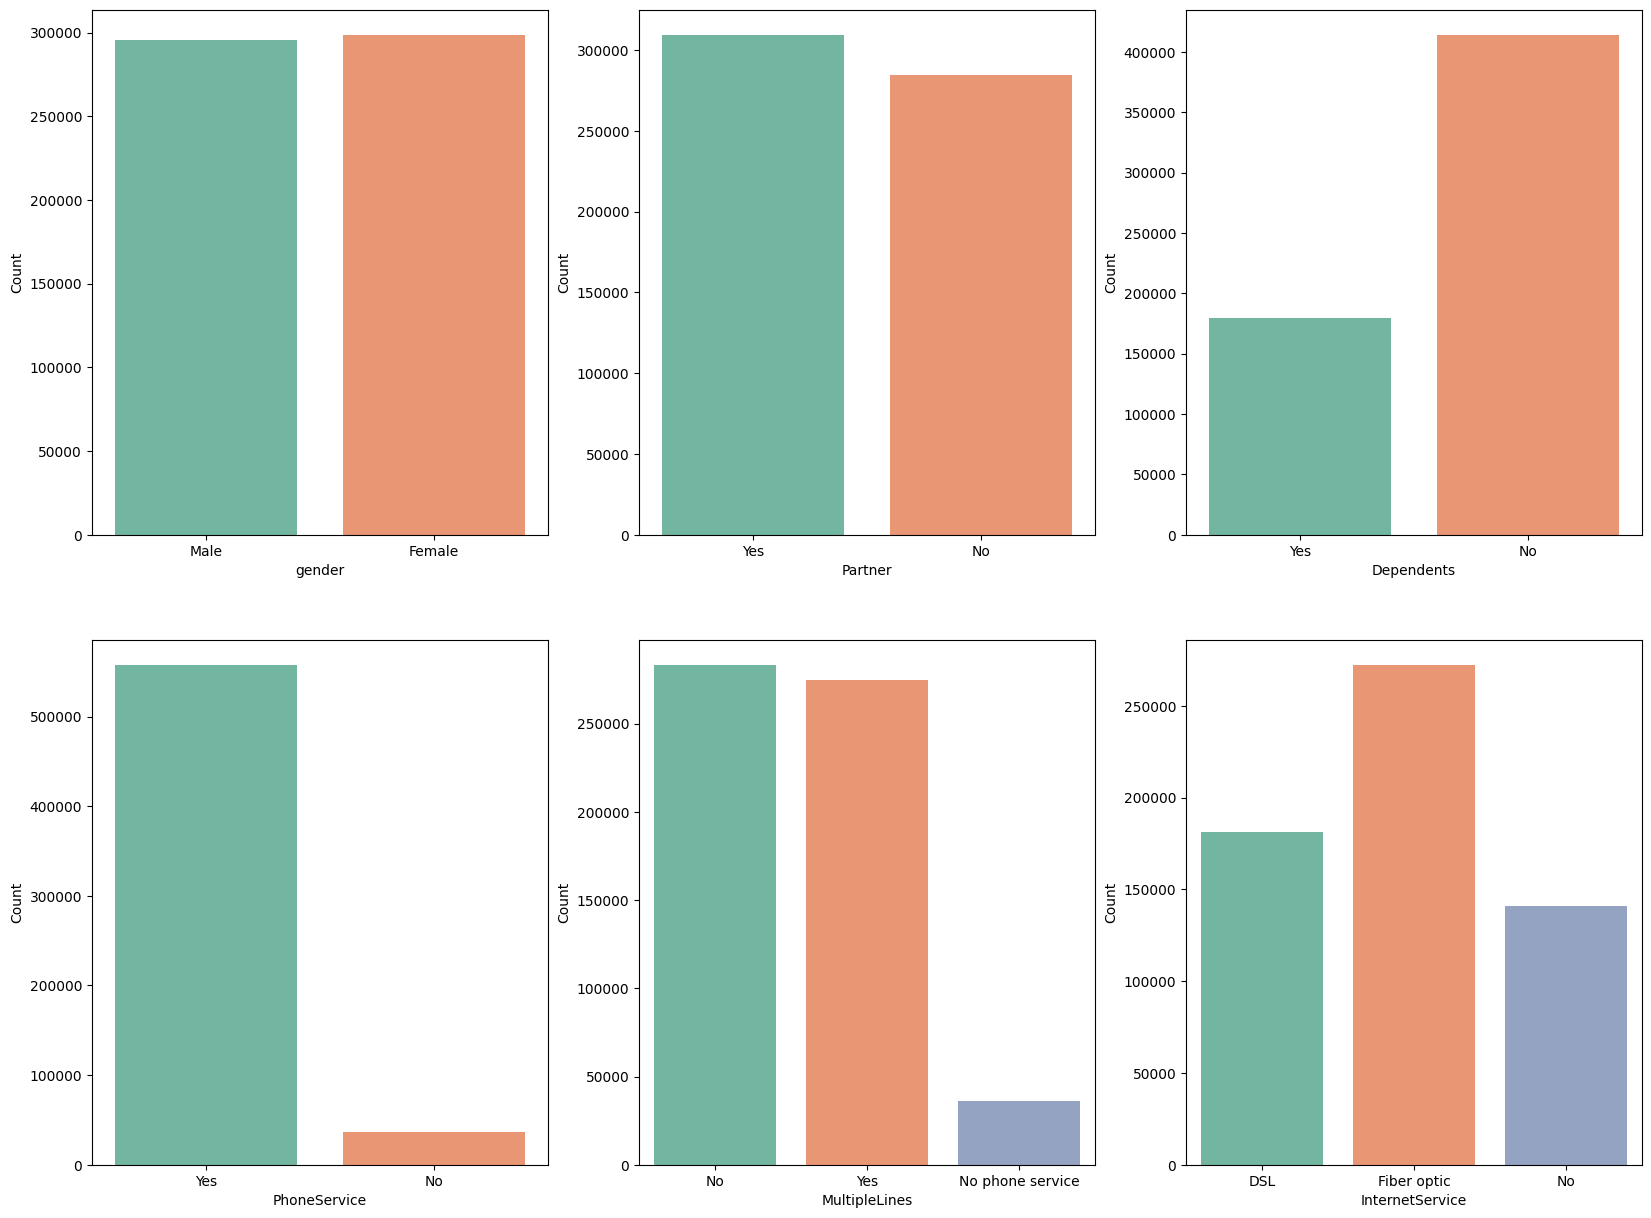

In [93]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_features[:6], 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=train_data, x=col, hue=col, palette="Set2", legend=False)
    plt.ylabel('Count')
plt.show()

## 6. Additional Internet Services

### OnlineSecurity
This feature indicates whether customers subscribe to an online security service.

- A large number of customers **do not subscribe to online security**.
- A smaller portion uses this service, while some customers fall under the **no internet service** category.

### OnlineBackup
This variable represents whether customers use an online backup service.

- Customers without online backup slightly outnumber those who have it.
- A noticeable group also has **no internet service**, which explains the third category.

### DeviceProtection
This feature indicates whether customers use device protection services.

- More customers **do not subscribe to device protection** than those who do.
- Similar to other internet-related services, some customers have **no internet service**.

### TechSupport
This variable shows whether customers have technical support services.

- Most customers **do not subscribe to tech support**.
- A smaller but still significant group does use this service, while some have **no internet service**.

---

## 7. Streaming Services

### StreamingTV
This feature indicates whether customers subscribe to TV streaming services.

- Slightly more customers **use streaming TV** compared to those who do not.
- A portion of customers falls under **no internet service**, explaining the third category.

### StreamingMovies
This variable represents movie streaming subscriptions.

- The distribution is similar to StreamingTV, with slightly more customers **subscribing to streaming movies**.
- A noticeable portion of customers again appears in the **no internet service** category.


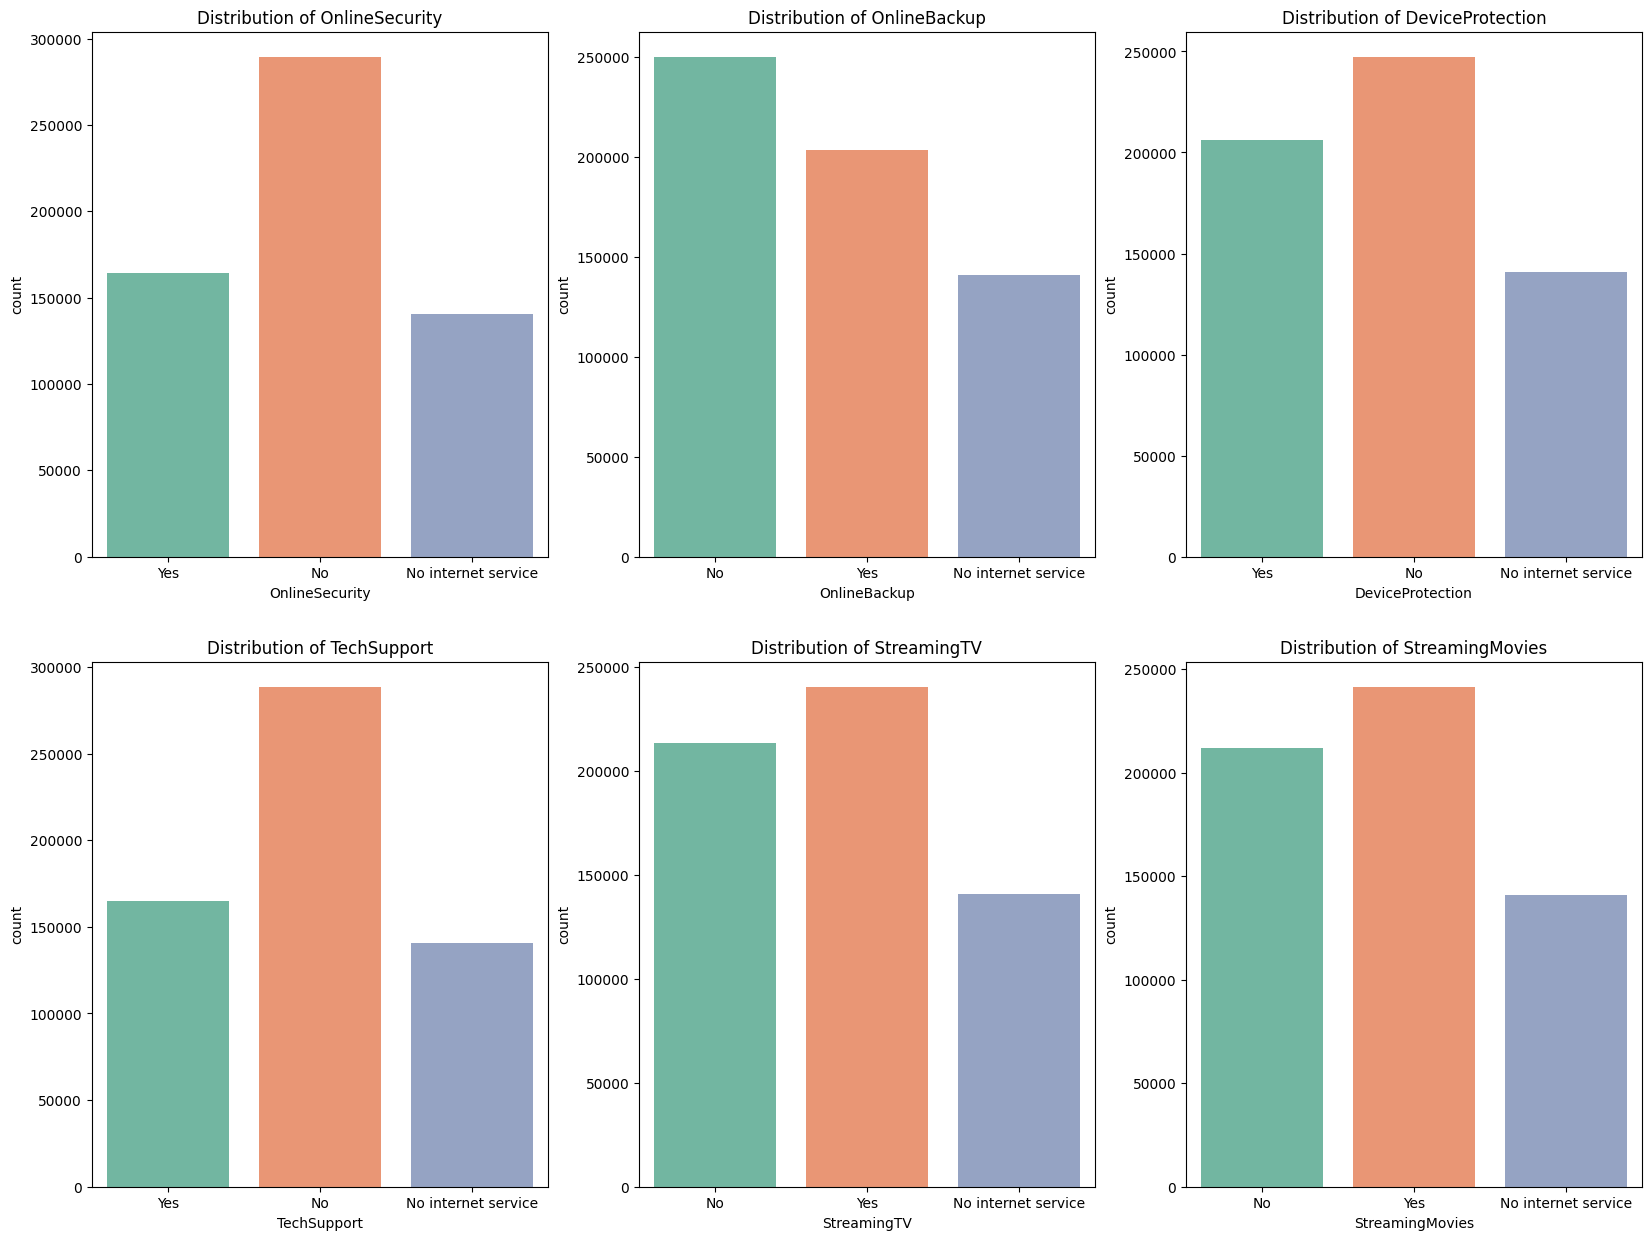

In [94]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_features[6:12], 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=train_data, x=col, hue=col, palette="Set2", legend=False)
    plt.title(f'Distribution of {col}')
plt.show()

## 4. Contract Information

### Contract Type
This variable describes the customer's contract duration.

- **Month-to-month contracts dominate the dataset**, representing the largest group of customers.
- **Two-year contracts** form the second-largest group.
- **One-year contracts** are the least common.
- The high number of month-to-month contracts suggests customers may have high flexibility, which can influence churn behavior.

---

## 5. Billing Preferences

### PaperlessBilling
This feature indicates whether customers use electronic billing.

- A majority of customers **prefer paperless billing**
- A majority of customers **prefer paperless billing** over traditional paper billing.
- However, a substantial portion still uses non-paperless billing methods, indicating mixed billing preferences.

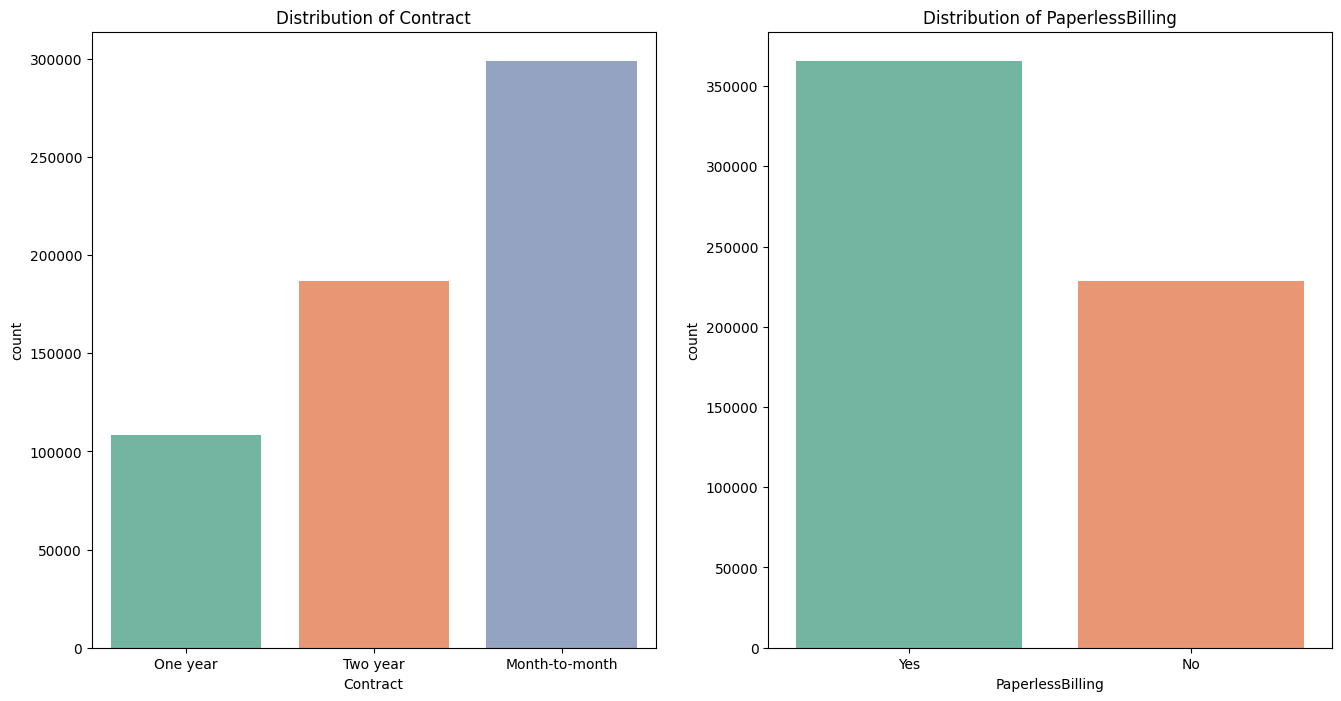

In [95]:
plt.figure(figsize=(16, 8))
for i, col in enumerate(cat_features[12:14], 1):
    plt.subplot(1, 2, i)
    sns.countplot(data=train_data, x=col, hue=col, palette="Set2", legend=False)
    plt.title(f'Distribution of {col}')
plt.show()

## Target Variable Distribution
* Churn:
    * This is the target variable to predict, and the plot reveals a distinct class imbalance.
    * Approximately 77% (450,000) of the customers stayed with the bank (No = 0).
    * Only about 23% (~2,000) churned (Yes = 1).

* Note on Imbalance: This means we will likely need to use evaluation metrics like F1-score or AUC-ROC rather than simple accuracy when evaluating our future predictive models.

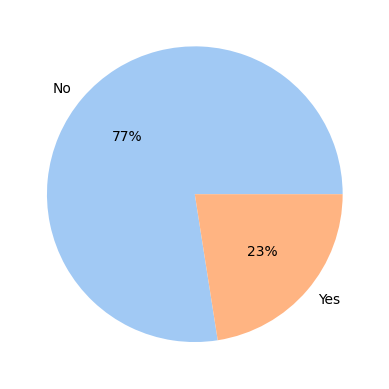

In [96]:
Churn_values = train_data["Churn"].value_counts().values
Churn_categories = train_data["Churn"].value_counts().index

colors = sns.color_palette('pastel')[0:5] 

plt.pie(Churn_values, labels=Churn_categories, colors=colors, autopct='%.0f%%');

## Univariate Analysis: Numerical Features

### SeniorCitizen
- This is actually a binary feature (0 or 1) disguised as numerical
- About 11.4% of customers are senior citizens (value = 1)
- This feature might be better treated as categorical in some models

### Tenure
- Ranges from 1 to 72 months (6 years)
- Mean tenure is about 36.6 months (3 years)
- Median is 35 months, suggesting a fairly symmetric distribution
- Standard deviation is about 25 months, indicating considerable variation

### MonthlyCharges
- Ranges from $18.25 to $118.75
- Mean is about $65.87 with a median of $74.10
- Slight negative skew (-0.29) indicating most customers pay higher monthly charges
- Standard deviation of about $31.07 shows significant variation in pricing

### TotalCharges
- Ranges from $18.80 to $8684.80
- Mean is about $2494.38 with a median of $1433.65
- Strong positive skew (0.91) indicating most customers have lower total charges
- Very high standard deviation ($2353.92) showing extreme variation

In [ ]:
from src.utils import univariate_analysis
# Numerical Features Analysis
num_features = train_data.select_dtypes(include=["int64", "float64"]).columns

# Display basic statistics for numerical features
univariate_analysis(train_data[num_features])

UNIVARIATE ANALYSIS SUMMARY
feature    SeniorCitizen  tenure MonthlyCharges TotalCharges
count             594194  594194         594194       594194
missing                0       0              0            0
unique                 2      72           1921        31910
dtype              int64   int64        float64      float64
is_numeric          True    True           True         True
min               0.0000  1.0000        18.2500      18.8000
max               1.0000 72.0000       118.7500    8684.8000
mean              0.1141 36.5773        65.8662    2494.3771
median            0.0000 35.0000        74.1000    1433.6500
mode              0.0000 72.0000        20.0500    6096.9000
std               0.3179 25.0619        31.0674    2353.9167
q25               0.0000 12.0000        29.9000     639.6500
q50               0.0000 35.0000        74.1000    1433.6500
q75               0.0000 62.0000        90.8000    4263.8000
skew              2.4275  0.0631        -0.2895       0.9

[{'feature': 'SeniorCitizen',
  'count': np.int64(594194),
  'missing': np.int64(0),
  'unique': 2,
  'dtype': dtype('int64'),
  'is_numeric': True,
  'min': np.int64(0),
  'max': np.int64(1),
  'mean': np.float64(0.1141024648515468),
  'median': np.float64(0.0),
  'mode': np.int64(0),
  'std': np.float64(0.31793594085071664),
  'q25': np.float64(0.0),
  'q50': np.float64(0.0),
  'q75': np.float64(0.0),
  'skew': np.float64(2.4275257022803975),
  'kurt': np.float64(3.892894138328813)},
 {'feature': 'tenure',
  'count': np.int64(594194),
  'missing': np.int64(0),
  'unique': 72,
  'dtype': dtype('int64'),
  'is_numeric': True,
  'min': np.int64(1),
  'max': np.int64(72),
  'mean': np.float64(36.577257596003996),
  'median': np.float64(35.0),
  'mode': np.int64(72),
  'std': np.float64(25.061921651851996),
  'q25': np.float64(12.0),
  'q50': np.float64(35.0),
  'q75': np.float64(62.0),
  'skew': np.float64(0.06305029865312908),
  'kurt': np.float64(-1.4871816314869981)},
 {'feature': 'Mo

## Numerical Feature Distributions

### SeniorCitizen Distribution
- As expected, this is a binary distribution with most customers being non-seniors (0)
- Only about 11% of customers are seniors, confirming our earlier statistics

### Tenure Distribution
- Shows a relatively uniform distribution across all tenure lengths
- Slight dip in the middle range (around 20-50 months)
- Peaks at both ends suggest customers either stay very briefly or for extended periods

### MonthlyCharges Distribution
- Bimodal distribution with peaks around $20 and $70-80
- Gap in the middle range ($30-60) suggests tiered pricing structures
- Long tail toward higher charges indicates premium service options

### TotalCharges Distribution
- Highly right-skewed with most customers having lower total charges
- Reflects the fact that newer customers (shorter tenure) have lower totals
- Very long tail shows some long-term customers with extremely high cumulative charges

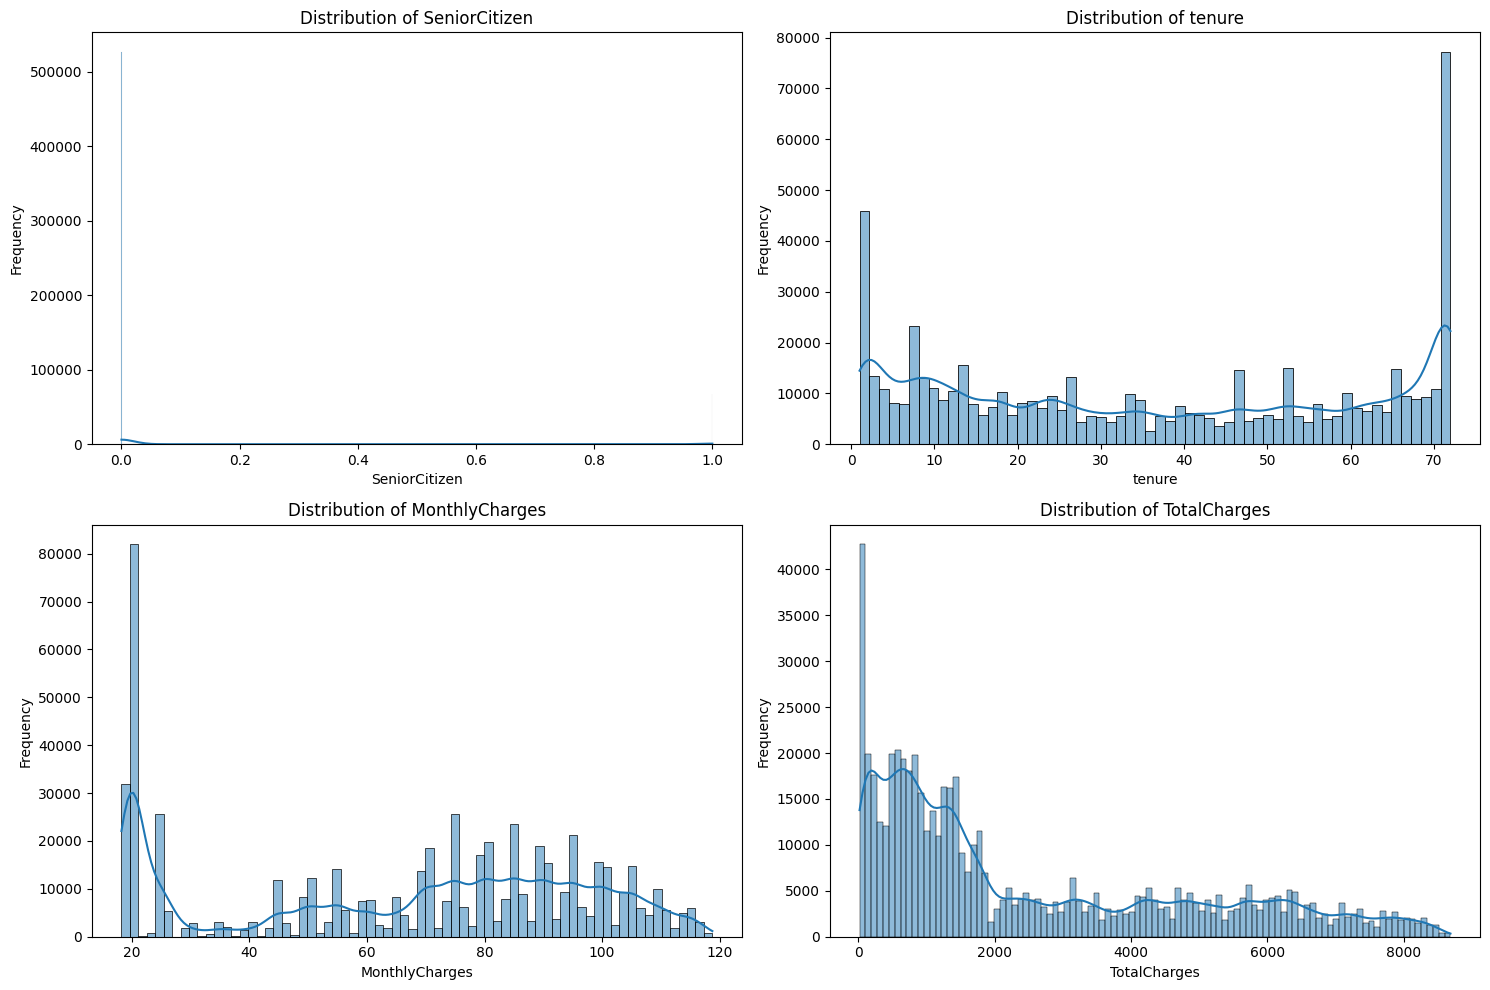

In [98]:
# Visualizing distributions of numerical features
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=train_data, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Bivariate Analysis: Numerical Features vs Churn

### SeniorCitizen and Churn
- Senior citizens (value = 1) show a slightly higher churn rate
- The boxplot shows that among churners, there's a higher proportion of seniors
- This suggests age may be a contributing factor to churn

### Tenure and Churn
- Clear distinction between churners and non-churners
- Churners have significantly lower tenure (median around 10 months)
- Non-churners have much higher tenure (median around 45 months)
- This makes intuitive sense - customers who stay longer are less likely to leave

### MonthlyCharges and Churn
- Churners tend to have slightly higher monthly charges
- Median monthly charge for churners is around $80 vs $65 for non-churners
- Higher charges might indicate dissatisfaction or financial constraints leading to churn

### TotalCharges and Churn
- Somewhat counterintuitive result - churners have lower total charges
- This aligns with the tenure observation since shorter tenure leads to lower totals
- Among customers with similar tenure, there might be different patterns

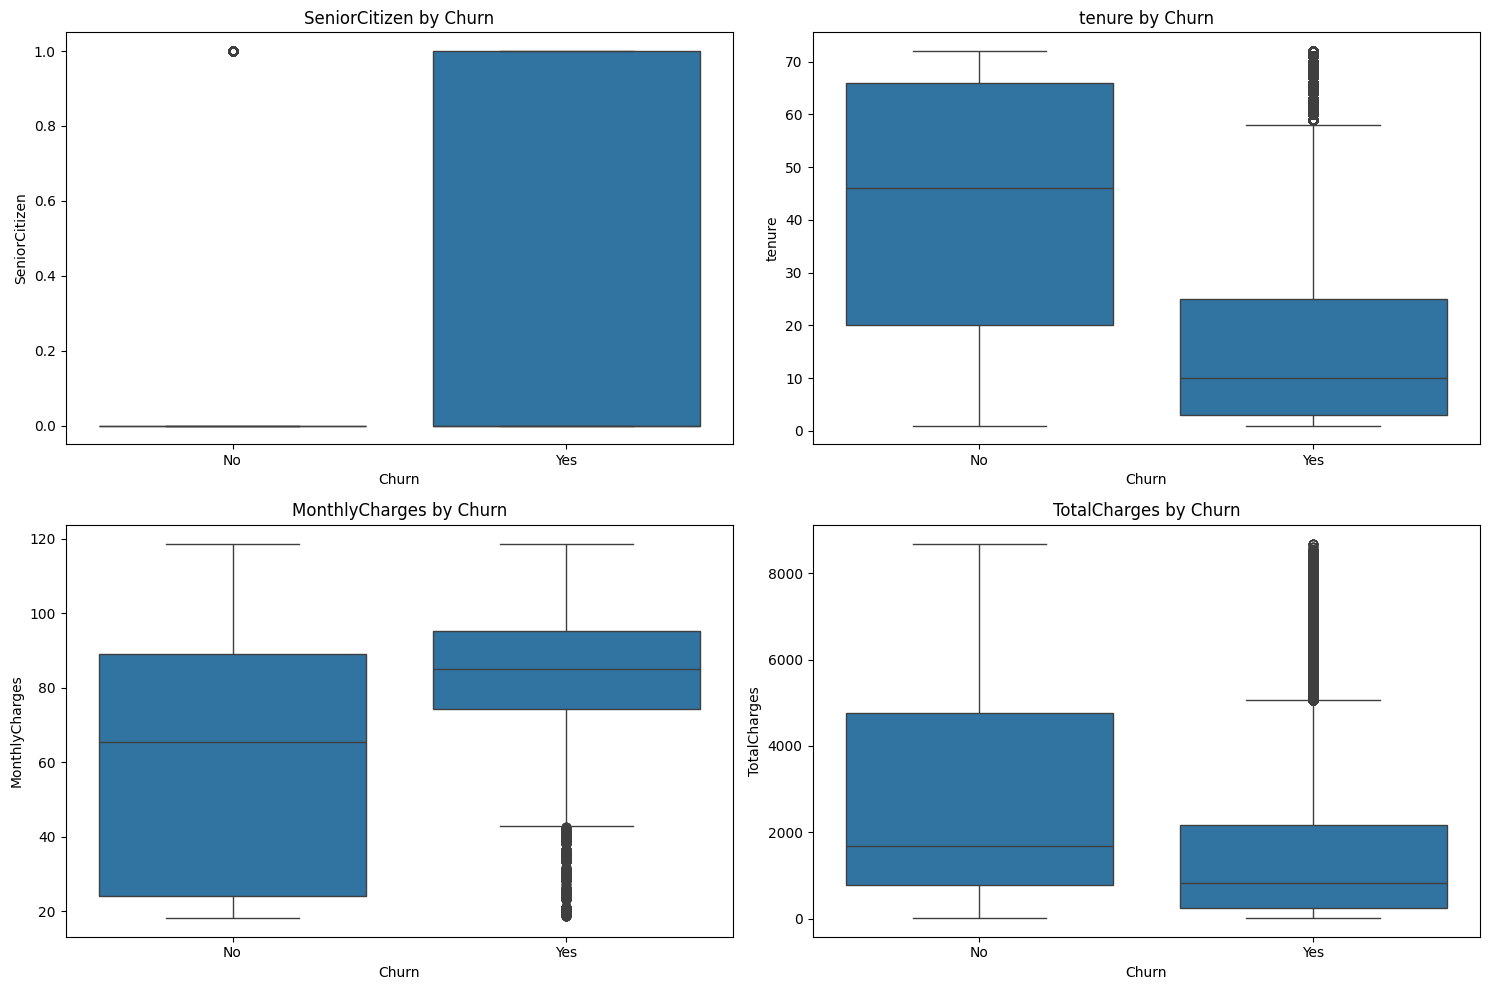

In [99]:
# Relationship between numerical features and Churn
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=train_data, x='Churn', y=col)
    plt.title(f'{col} by Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

## Feature Correlations (multicollinearity check)

### Strong Positive Correlations
- **Tenure and TotalCharges**: Very strong positive correlation (0.83)
  - Makes perfect sense - longer tenure leads to higher cumulative charges
  - This is expected behavior in subscription services

### Moderate Correlations
- **MonthlyCharges and SeniorCitizen**: Weak positive correlation (0.12)
  - Seniors tend to have slightly higher monthly charges
  - Could indicate different service preferences among age groups

### Near-Zero Correlations
- **SeniorCitizen and Tenure**: Very weak negative correlation (-0.02)
  - Minimal relationship between age and how long customers stay
- **SeniorCitizen and TotalCharges**: Weak positive correlation (0.08)
  - Seniors have slightly higher total charges, likely due to longer average tenure

### Implications for Modeling
- The strong correlation between tenure and TotalCharges suggests multicollinearity
- We might consider removing one of these features or combining them
- SeniorCitizen has weak relationships with other numerical features, so it provides unique information

Correlation Matrix:
                SeniorCitizen  tenure  MonthlyCharges  TotalCharges
SeniorCitizen          1.0000 -0.0843          0.2291        0.0428
tenure                -0.0843  1.0000          0.1240        0.7697
MonthlyCharges         0.2291  0.1240          1.0000        0.6342
TotalCharges           0.0428  0.7697          0.6342        1.0000


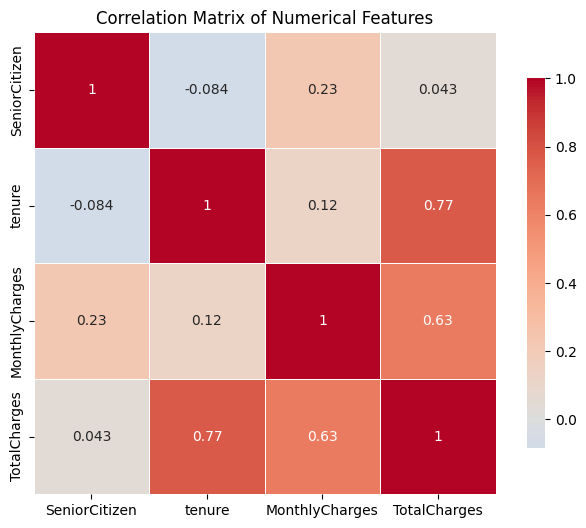

In [100]:
# Correlation analysis for numerical features
correlation_matrix = train_data[num_features].corr()
print("Correlation Matrix:")
print(correlation_matrix)

# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Observations on Outliers

### Tenure Outliers
- Very few outliers detected (< 0.1%)
- Boxplot shows relatively compact distribution
- These outliers are likely legitimate long-term customers

### MonthlyCharges Outliers
- Small percentage of outliers (likely < 1%)
- These represent customers paying premium rates
- May include customers with multiple services or premium packages

### TotalCharges Outliers
- Higher percentage of outliers due to the skewed distribution
- Represents long-term customers with high cumulative charges
- These are legitimate business cases, not data errors

### SeniorCitizen Outliers
- Binary feature, so no traditional outliers
- The 1.5 IQR rule doesn't apply meaningfully here

### Treatment Strategy
- Given the business context, these outliers appear to be valid data points
- Removing them could eliminate important customer segments
- For modeling, we'll keep them but consider transformations for highly skewed features

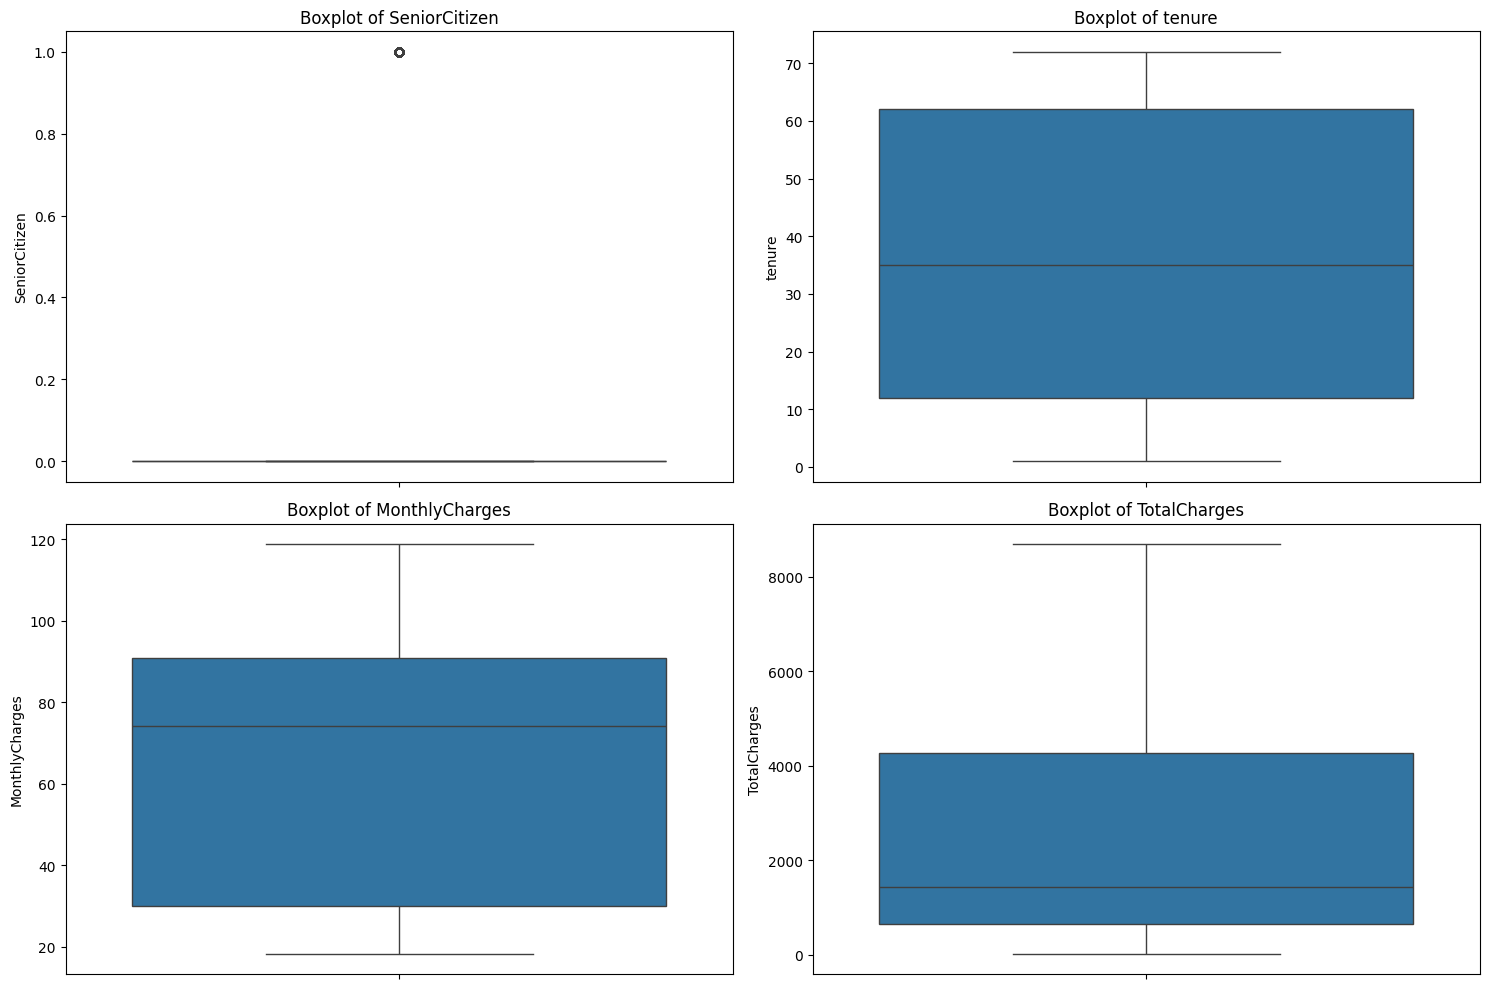

Outlier Analysis:
SeniorCitizen: 11.41% outliers
tenure: 0.00% outliers
MonthlyCharges: 0.00% outliers
TotalCharges: 0.00% outliers


In [101]:
# Outlier detection for numerical features
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=train_data, y=col)
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

# Calculate outlier statistics
print("Outlier Analysis:")
for col in num_features:
    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = train_data[(train_data[col] < lower_bound) | (train_data[col] > upper_bound)]
    outlier_percentage = (len(outliers) / len(train_data)) * 100
    print(f"{col}: {outlier_percentage:.2f}% outliers")

## Preprocessing Preparation

### Dataset Overview
- We have 594,194 rows and 20 columns (after removing 'id')
- The target variable 'Churn' is heavily imbalanced (77% No, 23% Yes)
- Data types are mostly appropriate, with some potential for optimization

### Key Preprocessing Steps Identified
1. **Feature Engineering**: 
   - SeniorCitizen should be treated as categorical despite being numeric
   - Potential ratio features (e.g., MonthlyCharges/Tenure)

2. **Encoding Requirements**:
   - All categorical variables need encoding for machine learning models
   - Special handling needed for "No internet service" and similar categories

3. **Scaling Requirements**:
   - Numerical features have different scales and distributions
   - Some are skewed and might benefit from transformation

4. **Handling Imbalance**:
   - The significant class imbalance in Churn will need addressing during modeling

In [102]:
# Data Preprocessing Preparation

# Let's first examine the current state of our data
print("Dataset Shape:", train_data.shape)
print("\nColumn Names:")
print(train_data.columns.tolist())

print("\nTarget Variable Distribution:")
print(train_data['Churn'].value_counts(normalize=True))

# Check if we need to handle any data type conversions
print("\nData Types:")
print(train_data.info())

Dataset Shape: (594194, 20)

Column Names:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Target Variable Distribution:
Churn
No    0.7748
Yes   0.2252
Name: proportion, dtype: float64

Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  str    
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  str    
 3   Dependents        594194 non-null  str    
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  str    
 6   MultipleLines     594194 non-null  str    
 7   I

##  Feature Engineering

### SeniorCitizen Conversion
- Converted from integer to string to treat as categorical
- This better reflects its nature as a demographic category rather than a numerical value

### AvgMonthlyCharge Feature
- Calculates average charge per month of tenure
- Helps normalize TotalCharges by tenure, providing insight into spending consistency
- Avoids division by zero by adding 1 to tenure

### ServiceCount Feature
- Counts how many services a customer subscribes to
- Accounts for special categories like "No internet service"
- Provides insight into customer engagement and potential dependency on services

### Benefits of Feature Engineering
- Creates more meaningful representations of customer behavior
- Reduces multicollinearity between tenure and TotalCharges
- Adds domain-specific insights that models might miss

In [103]:
# Feature Engineering

# Convert SeniorCitizen to categorical
train_data['SeniorCitizen'] = train_data['SeniorCitizen'].astype(str)

# Create new features based on domain knowledge
# Average monthly charge per year of tenure
train_data['AvgMonthlyCharge'] = train_data['TotalCharges'] / (train_data['tenure'] + 1)  # Adding 1 to avoid division by zero


# Service density - how many services a customer has
service_cols = ['PhoneService', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Count active services (excluding "No internet service" and similar)
train_data['ServiceCount'] = 0
for col in service_cols:
    if col == 'InternetService':
        train_data['ServiceCount'] += (train_data[col] != 'No').astype(int)
    elif col == 'PhoneService':
        train_data['ServiceCount'] += (train_data[col] == 'Yes').astype(int)
    else:
        # For services that can be "Yes", "No", or "No internet service"
        train_data['ServiceCount'] += (train_data[col] == 'Yes').astype(int)

print("New Features Created:")
print("- SeniorCitizen converted to categorical")
print("- AvgMonthlyCharge: Average charge per month of tenure")
print("- ServiceCount: Number of services subscribed to")

# Display updated dataset info
print("\nUpdated Dataset Info:")
print("Shape:", train_data.shape)
print("New columns:", [col for col in train_data.columns if col not in ['SeniorCitizen', 'AvgMonthlyCharge', 'ServiceCount']])

# Show sample of new features
print("\nSample of new features:")
print(train_data[['SeniorCitizen', 'AvgMonthlyCharge', 'ServiceCount']].head())

New Features Created:
- SeniorCitizen converted to categorical
- AvgMonthlyCharge: Average charge per month of tenure
- ServiceCount: Number of services subscribed to

Updated Dataset Info:
Shape: (594194, 22)
New columns: ['gender', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Sample of new features:
  SeniorCitizen  AvgMonthlyCharge  ServiceCount
0             0           55.1283             5
1             0           64.0373             6
2             0           99.0059             5
3             0           35.3500             2
4             0           35.2250             2


## Engineered Features Visualization

### AvgMonthlyCharge Distribution
- Shows a more normalized distribution compared to raw TotalCharges
- Most customers have an average monthly charge between $20-80
- Peak around $70 suggests common pricing tiers
- Reduced skewness makes it more suitable for linear models

### ServiceCount Distribution
- Most customers subscribe to 3-6 services
- Very few customers subscribe to all services (8)
- Some customers have minimal service subscriptions (0-2)
- This distribution reflects varied customer engagement levels

### ServiceCount vs Churn Relationship
- Clear trend: customers with more services are less likely to churn
- Customers with 0-1 services show highest churn rates
- Customers with 6+ services show lowest churn rates
- This validates the business intuition that service bundling increases retention

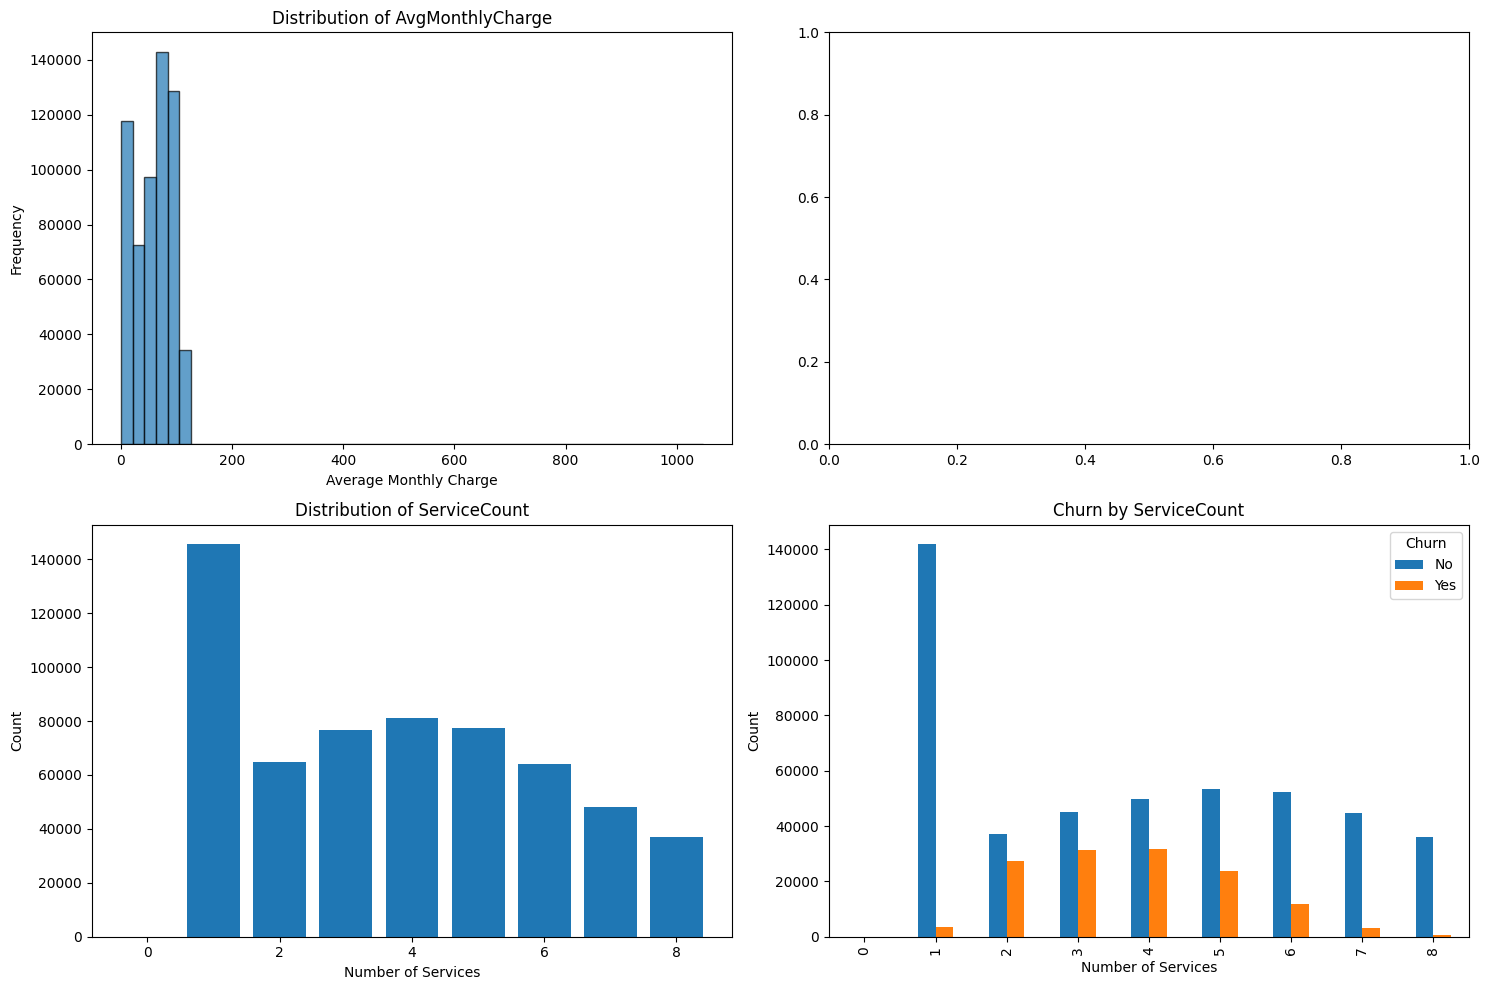

Statistics for Engineered Features:

AvgMonthlyCharge:
count   594194.0000
mean        61.5272
std         36.7495
min          0.7241
25%         25.4696
50%         64.9814
75%         86.9543
max       1046.9083
Name: AvgMonthlyCharge, dtype: float64
ServiceCount
0         7
1    145480
2     64633
3     76582
4     81297
5     77253
6     63941
7     48140
8     36861
Name: count, dtype: int64


In [108]:
# Visualize new engineered features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution of AvgMonthlyCharge
axes[0,0].hist(train_data['AvgMonthlyCharge'], bins=50, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Distribution of AvgMonthlyCharge')
axes[0,0].set_xlabel('Average Monthly Charge')
axes[0,0].set_ylabel('Frequency')

# Distribution of ServiceCount
service_count_dist = train_data['ServiceCount'].value_counts().sort_index()
axes[1,0].bar(service_count_dist.index, service_count_dist.values)
axes[1,0].set_title('Distribution of ServiceCount')
axes[1,0].set_xlabel('Number of Services')
axes[1,0].set_ylabel('Count')

# Relationship between ServiceCount and Churn
churn_by_service_count = train_data.groupby(['ServiceCount', 'Churn']).size().unstack(fill_value=0)
churn_by_service_count.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Churn by ServiceCount')
axes[1,1].set_xlabel('Number of Services')
axes[1,1].set_ylabel('Count')
axes[1,1].legend(title='Churn')

plt.tight_layout()
plt.show()

# Print statistics for new features
print("Statistics for Engineered Features:")
print("\nAvgMonthlyCharge:")
print(train_data['AvgMonthlyCharge'].describe())


print(train_data['ServiceCount'].value_counts().sort_index())

## Data Preparation For Modeling
### Dataset Structure
- Features matrix (X): 594,194 rows Ã— 23 columns (including 3 new engineered features)
- Target vector (y): 594,194 values
- Good balance between features and samples for machine learning

### Feature Categories
- **Numeric Features (4)**: tenure, MonthlyCharges, TotalCharges, AvgMonthlyCharge
- **Categorical Features (19)**: All other features including engineered ones (SeniorCitizen, HighValueCustomer, ServiceCount)

### Data Quality Check Results
- No infinite values detected
- No NaN values detected
- Data is clean and ready for preprocessing

### Next Steps
1. **Normalization**: Scale numeric features to comparable ranges
2. **Encoding**: Convert categorical features to numerical representations
3. **Stratified Splitting**: Maintain class distribution in train/Validation splits
4. **Cross-validation Setup**: Prepare for robust model evaluation

- **Important Note**: Since we are already working on trainin data since the beginning we will go ahead with the preproccessing, but for another projects where we need to split the data to train test split by ourselves, we should do the preproccessing after the split to prevent data leakage

In [106]:
# Separate features and target
X = train_data.drop('Churn', axis=1)
y = train_data['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Identify feature types for preprocessing
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'str']).columns.tolist()

print("\nNumeric Features:")
print(numeric_features)
print("\nCategorical Features:")
print(categorical_features)

# Check for any remaining data quality issues
print("\nChecking for infinite values:")
inf_count = X.isin([np.inf, -np.inf]).sum().sum()
print(f"Infinite values: {inf_count}")

print("\nChecking for NaN values:")
nan_count = X.isnull().sum().sum()
print(f"NaN values: {nan_count}")

# Display final dataset info before splitting
print("\nFinal Dataset Info:")
print("Total features:", len(X.columns))
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Features shape: (594194, 21)
Target shape: (594194,)

Numeric Features:
['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyCharge', 'ServiceCount']

Categorical Features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Checking for infinite values:
Infinite values: 0

Checking for NaN values:
NaN values: 0

Final Dataset Info:
Total features: 21
Numeric features: 5
Categorical features: 16


## Data Splitting

### Stratified Sampling Success
- Training set: 475,355 samples (80%)
- Validation set: 118,839 samples (20%)
- Churn rates maintained across splits (approximately 23% in all sets)
- This ensures representative samples for both training and evaluation

### Dataset Size Considerations
- Large dataset enables robust training
- Sufficient test set size for reliable performance evaluation
- Memory considerations for preprocessing the full dataset
- Appropriate split ratio for this type of business problem

### Reproducibility Measures
- Fixed random_state=42 for consistent results
- Same split will be reproduced in future runs
- Enables comparison of different modeling approaches

### Next Steps Completed
1. EDA completed with detailed observations
2. Feature engineering implemented
3. Data preprocessing pipeline created
4. Data splitting completed with stratification

### Ready for Modeling
- Training and test sets properly separated
- Preprocessing pipeline validated and ready
- Class distributions maintained appropriately
- Data integrity verified throughout process

In [107]:
# Data Splitting Preparation

from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
# Using stratified sampling to maintain class distribution
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2,  # 80% train, 20% test
    random_state=42,  # For reproducibility
    stratify=y  # Maintain class distribution
)

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val  = le.transform(y_val)

print("Data Splitting Complete:")
print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")

# Verify shapes
print("\nSplit Shapes:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

# Save the splits for later use
print("\nData splits ready for preprocessing and modeling.")

Data Splitting Complete:
Training set size: 475355 samples (80.0%)
Test set size: 118839 samples (20.0%)

Split Shapes:
X_train: (475355, 21)
X_val: (118839, 21)
y_train: (475355,)
y_val: (118839,)

Data splits ready for preprocessing and modeling.


In [ ]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')
smote = SMOTE(random_state=42)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)



models = {
    "Hist Gradient Boosting Classifier": HistGradientBoostingClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Neural Network (MLP)": MLPClassifier(max_iter=1000, random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results_list = []

for name, model in models.items():
    print(f"Training {name}...")

    # ✅ Build a fresh pipeline per model, including the classifier as the final step
    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("smote", smote),
        ("model", model)
    ])

    cv_scores = cross_validate(
        pipeline, 
        X_train, 
        y_train,
        cv=skf,
        scoring=['accuracy', 'f1', 'roc_auc']
    )

    cv_results_list.append({
        'Model': name,
        'Accuracy': cv_scores['test_accuracy'].mean(),
        'F1-Score': cv_scores['test_f1'].mean(),
        'ROC-AUC': cv_scores['test_roc_auc'].mean()
    })

results_df = pd.DataFrame(cv_results_list)
print("\nCross-Validation Results:")
display(results_df.sort_values(by='ROC-AUC', ascending=False))

Training Hist Gradient Boosting Classifier...
Training LightGBM...

Cross-Validation Results:


,Model,Accuracy,F1-Score,ROC-AUC
0,Hist Gradient Boosting Classifier,0.8283,0.6896,0.9134
1,LightGBM,0.8365,0.6940,0.9131


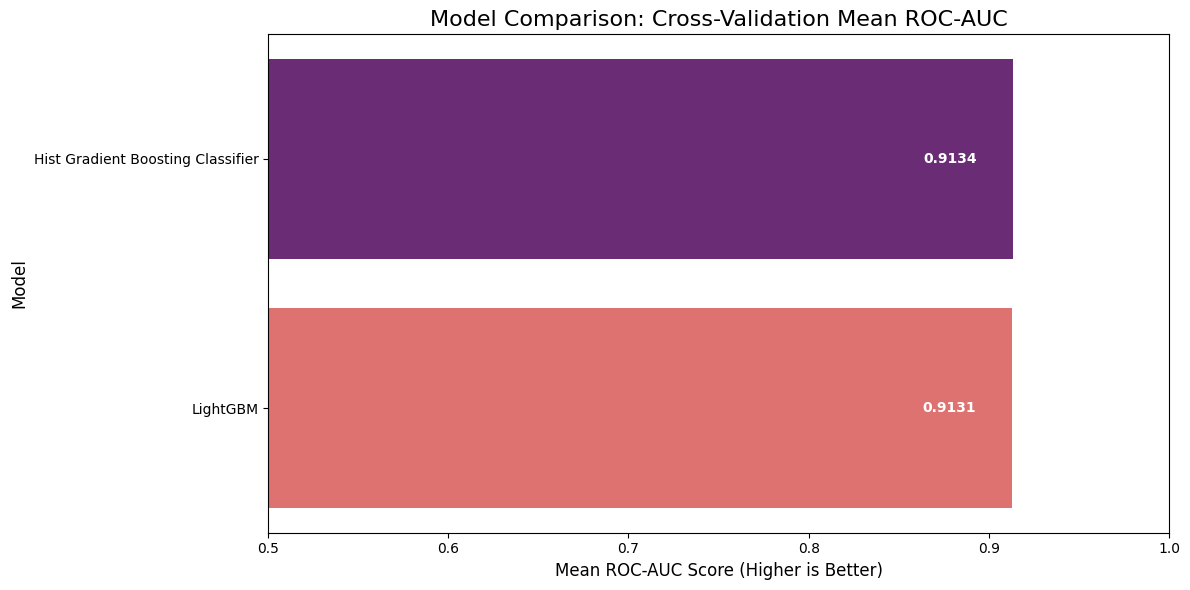

In [119]:
results_df_sorted = results_df.sort_values(by='ROC-AUC', ascending=False)

plt.figure(figsize=(12, 6))
barplot = sns.barplot(x='ROC-AUC', y='Model', data=results_df_sorted, palette='magma')

for index, value in enumerate(results_df_sorted['ROC-AUC']):
    plt.text(value - 0.05, index, f'{value:.4f}', color='white', va='center', fontweight='bold')

plt.title('Model Comparison: Cross-Validation Mean ROC-AUC', fontsize=16)
plt.xlabel('Mean ROC-AUC Score (Higher is Better)', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0.5, 1.0) 
plt.tight_layout()
plt.show()

In [123]:
print("Tuning LightGBM...")

lgbm_param_grid = {
    'model__n_estimators':  [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth':     [-1, 7, 10],
    'model__num_leaves':    [31, 50]
}

grid_search_lgbm = GridSearchCV(
    LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    lgbm_param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1       # parallelize across folds too
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("smote",      smote),
    ("model",      grid_search_lgbm)
])

pipeline.fit(X_train, y_train)

# Access results cleanly through the pipeline step
best_lgbm = pipeline.named_steps['model']
print("Best Parameters:", best_lgbm.best_params_)
print("Best ROC-AUC:   ", best_lgbm.best_score_.round(4))

Tuning LightGBM...
Best Parameters: {'model__learning_rate': 0.01, 'model__max_depth': -1, 'model__n_estimators': 100, 'model__num_leaves': 31}
Best ROC-AUC:    0.9439


In [124]:
val_preds = pipeline.predict(X_val)
val_probs = pipeline.predict_proba(X_val)[:, 1]

print("Final Model Results (Test Set):")
print(f"Accuracy: {accuracy_score(y_val, val_preds):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, val_probs):.4f}")
print("\nClassification Report:\n", classification_report(y_val, val_preds))

Final Model Results (Test Set):
Accuracy: 0.8346
ROC-AUC: 0.9136

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.84      0.89     92076
           1       0.60      0.83      0.69     26763

    accuracy                           0.83    118839
   macro avg       0.77      0.83      0.79    118839
weighted avg       0.87      0.83      0.84    118839



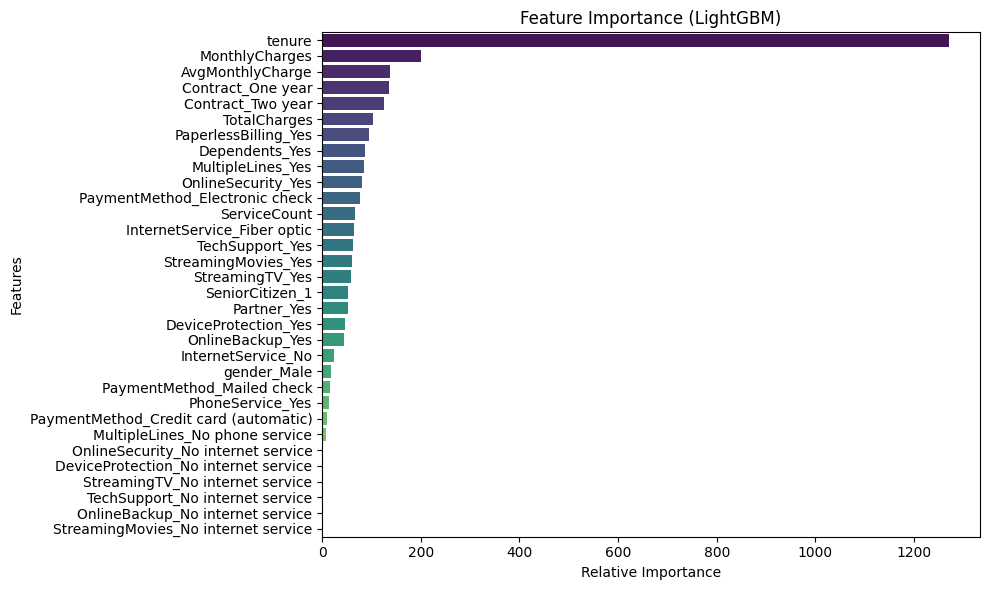

In [115]:
feature_names = (
    numeric_features +
    list(pipeline.named_steps['preprocess']
         .named_transformers_['cat']
         .get_feature_names_out(categorical_features))
)

importances = best_lgbm.best_estimator_.feature_importances_

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance (LightGBM)')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [142]:
# Load test data
test_df = pd.read_csv('data/test.csv')
test_ids = test_df['id']
X_test = test_df.drop(columns=['id'])

# ── Feature Engineering (mirror of train) ────────────────────────────────────
X_test['SeniorCitizen'] = X_test['SeniorCitizen'].astype(str)

X_test['AvgMonthlyCharge'] = X_test['TotalCharges'] / (X_test['tenure'] + 1)


service_cols = ['PhoneService', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

X_test['ServiceCount'] = 0
for col in service_cols:
    if col == 'InternetService':
        X_test['ServiceCount'] += (X_test[col] != 'No').astype(int)
    else:
        X_test['ServiceCount'] += (X_test[col] == 'Yes').astype(int)

# ── Predict & Submit ──────────────────────────────────────────────────────────
test_preds = pipeline.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({'id': test_ids, 'Churn': test_preds})
submission.to_csv('submission.csv', index=False)

print(f"Shape: {submission.shape}")
print(f"Churn distribution:\n{submission['Churn'].value_counts()}")

Shape: (254655, 2)
Churn distribution:
Churn
0.0056    196
0.0058    186
0.0057    183
0.0054    180
0.0793    164
         ... 
0.7244      1
0.6753      1
0.4309      1
0.0095      1
0.6221      1
Name: count, Length: 169160, dtype: int64


In [143]:
submission

,id,Churn
0,594194,0.1563
1,594195,0.0034
2,594196,0.1751
3,594197,0.0073
4,594198,0.6846
...,...,...
254650,848844,0.0027
254651,848845,0.9016
254652,848846,0.4309
254653,848847,0.0095


In [147]:
import joblib

# Save
joblib.dump(pipeline, 'models/pipeline_lgbm.pkl')
print("Model saved!")

Model saved!


In [1]:
from src.exception import CustomException
from src.logger import logging
from src.utils import evaluate_models, save_object, train_neural_network, save_torch_model